In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
file_path = '/content/drive/My Drive/Zahra/IranStockExchange.xlsx'
df = pd.read_excel(file_path)
print(df.head())

Mounted at /content/drive
   ID       Firm  Year     Industry Symbol    Cash  Short term investment  \
0   1  البرزدارو  1394  مواد دارویی  دالبر   24669                      0   
1   1  البرزدارو  1395  مواد دارویی  دالبر  182875                      0   
2   1  البرزدارو  1396  مواد دارویی  دالبر   22583                      0   
3   1  البرزدارو  1397  مواد دارویی  دالبر  212555                      0   
4   1  البرزدارو  1398  مواد دارویی  دالبر  174887                      0   

   Tangible fixed assets  Current asset  Total assets  Current debt     debt  \
0                 271878        2555666       2852280       1147932  1159477   
1                 330917        3477074       3914815       1634294  1648153   
2                 468898        4806150       5284110       2531974  2551332   
3                 909434        6862026       8361010       4409486  4440731   
4                1065818        9237503      10905214       5462191  5489459   

        sale     tax  Profit b

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 18 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         1040 non-null   int64  
 1   Firm                                       1040 non-null   object 
 2   Year                                       1040 non-null   int64  
 3    Industry                                  1040 non-null   object 
 4   Symbol                                     1040 non-null   object 
 5   Cash                                       1040 non-null   int64  
 6   Short term investment                      1040 non-null   int64  
 7   Tangible fixed assets                      1040 non-null   int64  
 8   Current asset                              1040 non-null   int64  
 9   Total assets                               1040 non-null   int64  
 10  Current debt            

In [ ]:
print(df.shape)

(1040, 18)


In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/Zahra/IranStockExchange.xlsx"
sheet     = "Sheet1"

df = pd.read_excel(file_path, sheet_name=sheet)

numeric_cols = ['Cash', 'Short term investment', 'Short term investment',
                'Current asset', 'Total assets', 'Current debt', 'debt', 'sale',
                'tax', 'Profit before tax', 'net profit',
                'Operating cash flows for the current year']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if {'Current asset','Current debt'}.issubset(df.columns):
    df['current_ratio'] = df['Current asset'] / df['Current debt']

if {'debt','Total assets'}.issubset(df.columns):
    df['debt_to_equity'] = df['debt'] / (df['Total assets'] - df['debt'])

if {'net profit','sale'}.issubset(df.columns):
    df['net_profit_margin'] = df['net profit'] / df['sale']
    df['return_on_assets']  = df['net profit'] / df['Total assets']
    df['return_on_equity']  = df['net profit'] / (df['Total assets'] - df['debt'])

if {'tax','sale'}.issubset(df.columns):
    df['gross_margin'] = df['tax'] / df['sale']

if {'Profit before tax','sale'}.issubset(df.columns):
    df['operating_margin'] = df['Profit before tax'] / df['sale']

if {'sale','Total assets'}.issubset(df.columns):
    df['asset_turnover'] = df['sale'] / df['Total assets']

if {'Operating cash flows for the current year','debt'}.issubset(df.columns):
    df['cashflow_to_debt'] = df['Operating cash flows for the current year'] / df['debt']

df.to_csv("financial_ratios.csv", index=False)
print("Saved financial_ratios.csv")

Saved financial_ratios.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
file_path = '/content/drive/My Drive/Zahra/financial_ratios.csv'
df = pd.read_csv(file_path)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ID       Firm  Year     Industry Symbol    Cash  Short term investment  \
0   1  البرزدارو  1394  مواد دارویی  دالبر   24669                      0   
1   1  البرزدارو  1395  مواد دارویی  دالبر  182875                      0   
2   1  البرزدارو  1396  مواد دارویی  دالبر   22583                      0   
3   1  البرزدارو  1397  مواد دارویی  دالبر  212555                      0   
4   1  البرزدارو  1398  مواد دارویی  دالبر  174887                      0   

   Tangible fixed assets  Current asset  Total assets  ...  Tax paid  \
0                 271878        2555666       2852280  ...    183869   
1                 330917        3477074       3914815  ...    241174   
2                 468898        4806150       5284110  ...    311956   
3                 909434        6862026       8361010  ...    363310   
4                1065818        9237503      109

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 26 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         1040 non-null   int64  
 1   Firm                                       1040 non-null   object 
 2   Year                                       1040 non-null   int64  
 3    Industry                                  1040 non-null   object 
 4   Symbol                                     1040 non-null   object 
 5   Cash                                       1040 non-null   int64  
 6   Short term investment                      1040 non-null   int64  
 7   Tangible fixed assets                      1040 non-null   int64  
 8   Current asset                              1040 non-null   int64  
 9   Total assets                               1040 non-null   int64  
 10  Current debt            

In [ ]:
df.describe()

,ID,Year,Cash,Short term investment,Tangible fixed assets,Current asset,Total assets,Current debt,debt,sale,...,Tax paid,Operating cash flows for the current year,current_ratio,debt_to_equity,net_profit_margin,return_on_assets,return_on_equity,gross_margin,operating_margin,asset_turnover
count,1040.000000,1040.00000,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,1.040000e+03,...,1.040000e+03,1.040000e+03,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000
mean,65.500000,1397.50000,9.640865e+05,1.008441e+06,4.113559e+06,1.345892e+07,2.254839e+07,1.255403e+07,1.377524e+07,1.930824e+07,...,2.385098e+05,2.626115e+06,1.828952,1.713872,0.202353,0.147596,0.245667,0.024355,0.226708,0.947213
std,37.544712,2.29239,6.141317e+06,9.131345e+06,1.722180e+07,7.932620e+07,1.179232e+08,7.163973e+07,7.633622e+07,1.069338e+08,...,2.019055e+06,2.027197e+07,1.761772,7.402635,0.391692,0.158210,1.600409,0.028613,0.400647,0.605431
min,1.000000,1394.00000,4.370000e+02,0.000000e+00,9.736000e+03,3.224100e+04,7.296000e+04,1.190500e+04,1.640400e+04,1.674600e+04,...,0.000000e+00,-2.489394e+07,0.214718,-63.434612,-3.424832,-0.562895,-46.073992,0.000000,-3.424832,0.039308
25%,33.000000,1395.75000,2.647075e+04,0.000000e+00,2.282285e+05,8.260250e+05,1.345460e+06,5.374915e+05,6.365918e+05,1.038807e+06,...,4.474750e+03,4.445750e+04,1.111152,0.567638,0.041437,0.037544,0.104486,0.001584,0.049982,0.550420
50%,65.500000,1397.50000,9.904100e+04,2.600000e+02,5.695210e+05,2.075214e+06,3.116644e+06,1.425736e+06,1.625502e+06,2.519894e+06,...,2.651100e+04,2.492125e+05,1.437257,1.115218,0.145012,0.119826,0.296035,0.016642,0.170507,0.797762
75%,98.000000,1399.25000,3.303768e+05,5.463325e+04,1.671301e+06,5.706501e+06,9.168241e+06,3.913614e+06,4.472968e+06,7.388124e+06,...,8.853350e+04,8.872260e+05,1.980150,2.104276,0.310899,0.241359,0.510203,0.036078,0.348394,1.198534
max,130.000000,1401.00000,1.100532e+08,2.008178e+08,2.662953e+08,1.682738e+09,2.335883e+09,1.251650e+09,1.309065e+09,1.881503e+09,...,4.481599e+07,4.280329e+08,27.095449,195.018454,7.802988,0.681977,3.573006,0.342174,7.837376,5.776184


In [ ]:
"""
classify_company_risk.py
------------------------
طبقه‌بندی شرکت‌های بورسی بر اساس Debt-to-Equity:
    - High-Risk  : debt_to_equity > 1
    - Low-Risk   : debt_to_equity ≤ 1
"""

import pandas as pd
from pathlib import Path

# ───────────────────────────────────────────────────────────────
csv_path = Path("/content/drive/My Drive/Zahra/financial_ratios.csv")
sheet_name = "Sheet2"
# ───────────────────────────────────────────────────────────────
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()          # حذف فاصله‌های ناخواسته

for col in ['debt', 'Total assets']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'debt_to_equity' not in df.columns:
    df['debt_to_equity'] = df['debt'] / (df['Total assets'] - df['debt'])

threshold = 1.0
df['risk_class'] = (df['debt_to_equity'] > threshold) \
                   .map({True: 'High-Risk', False: 'Low-Risk'})

print("\n=== تعداد شرکت‌ها در هر کلاس ریسک ===")
print(df['risk_class'].value_counts())

out_file = Path("companies_risk_class.csv")
df.to_csv(out_file, index=False)
print(f"\nنتیجه در «{out_file}» ذخیره شد.")


=== تعداد شرکت‌ها در هر کلاس ریسک ===
risk_class
High-Risk    568
Low-Risk     472
Name: count, dtype: int64

نتیجه در «companies_risk_class.csv» ذخیره شد.


In [ ]:
"""
classify_company_risk_median.py
-------------------------------
طبقه‌بندی شرکت‌های بورسی بر اساس Debt-to-Equity با آستانهٔ متغیّر:
    - High-Risk : debt_to_equity > median
    - Low-Risk  : debt_to_equity ≤ median
"""

import pandas as pd
from pathlib import Path

csv_path = Path("/content/drive/My Drive/Zahra/financial_ratios.csv")
sheet_name = "Sheet3"


df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

for col in ['debt', 'Total assets']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


median_threshold = df['debt_to_equity'].median(skipna=True)
print(f"↳ آستانهٔ دینامیک (میانهٔ D/E): {median_threshold:0.3f}")

df['risk_class'] = (df['debt_to_equity'] > median_threshold)\
                   .map({True: 'High-Risk', False: 'Low-Risk'})

print("\n=== تعداد شرکت‌ها در هر کلاس ریسک ===")
print(df['risk_class'].value_counts(dropna=False))

out_file = Path("companies_risk_class_median.csv")
df.to_csv(out_file, index=False)
print(f"\nنتیجه در «{out_file}» ذخیره شد.")

↳ آستانهٔ دینامیک (میانهٔ D/E): 1.115

=== تعداد شرکت‌ها در هر کلاس ریسک ===
risk_class
Low-Risk     520
High-Risk    520
Name: count, dtype: int64

نتیجه در «companies_risk_class_median.csv» ذخیره شد.


In [ ]:
"""
classify_company_risk_p75.py
----------------------------
طبقه‌بندی شرکت‌های بورسی بر اساس Debt-to-Equity با آستانهٔ صدک ۷۵:
    - High-Risk : debt_to_equity > 75th percentile
    - Low-Risk  : debt_to_equity ≤ 75th percentile
"""

import pandas as pd
from pathlib import Path

csv_path = Path("/content/drive/My Drive/Zahra/financial_ratios.csv")
sheet_name = "Sheet4"


df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

for col in ['debt', 'Total assets']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

p75_threshold = df['debt_to_equity'].quantile(0.75, interpolation="midpoint")
print(f"↳ آستانهٔ دینامیک (صدک ۷۵ D/E): {p75_threshold:0.3f}")

df['risk_class'] = (df['debt_to_equity'] > p75_threshold) \
                   .map({True: 'High-Risk', False: 'Low-Risk'})

print("\n=== تعداد شرکت‌ها در هر کلاس ریسک ===")
print(df['risk_class'].value_counts(dropna=False))

out_file = Path("companies_risk_class_p75.csv")
df.to_csv(out_file, index=False)
print(f"\nنتیجه در «{out_file}» ذخیره شد.")

↳ آستانهٔ دینامیک (صدک ۷۵ D/E): 2.107

=== تعداد شرکت‌ها در هر کلاس ریسک ===
risk_class
Low-Risk     780
High-Risk    260
Name: count, dtype: int64

نتیجه در «companies_risk_class_p75.csv» ذخیره شد.


### **[SVM MODEL](https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/)**

In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

csv_path = Path("/content/drive/My Drive/Zahra/financial_ratios.csv")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

for col in ['debt', 'Total assets']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'debt_to_equity' not in df.columns:
    df['debt_to_equity'] = df['debt'] / (df['Total assets'] - df['debt'])

df = df.dropna(subset=['debt_to_equity'])

p75_threshold = df['debt_to_equity'].quantile(0.75, interpolation="midpoint")
print(f" آستانهٔ  (صدک ۷۵ D/E): {p75_threshold:.3f}")

# ایجاد ستون لیبل صفر و یک (کم ریسک=0، پرریسک=1)
df['risk_label'] = (df['debt_to_equity'] > p75_threshold).astype(int)

print("\n=== تعداد شرکت‌ها در هر کلاس ریسک ===")
print(df['risk_label'].value_counts())

# انتخاب ویژگی‌ها برای مدل (می‌توانید ستون‌های آماری بیشتر اضافه کنید)
features = ['debt_to_equity']

X = df[features].fillna(0)
y = df['risk_label']

# مقیاس‌بندی ویژگی‌ها (ضروری برای SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

svm_model = SVC(kernel='rbf', C=1, gamma='scale')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

out_file = Path("companies_risk_class_p75_with_label.csv")
df.to_csv(out_file, index=False)
print(f"\nنتیجه با ستون لیبل در «{out_file}» ذخیره شد.")


 آستانهٔ  (صدک ۷۵ D/E): 2.107

=== تعداد شرکت‌ها در هر کلاس ریسک ===
risk_label
0    780
1    260
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       146
           1       1.00      0.87      0.93        62

    accuracy                           0.96       208
   macro avg       0.97      0.94      0.95       208
weighted avg       0.96      0.96      0.96       208

Confusion Matrix:
[[146   0]
 [  8  54]]

نتیجه با ستون لیبل در «companies_risk_class_p75_with_label.csv» ذخیره شد.


In [ ]:
print(df[['Firm', 'Year', 'risk_label']].head(30))

           Firm  Year  risk_label
0     البرزدارو  1394           0
1     البرزدارو  1395           0
2     البرزدارو  1396           0
3     البرزدارو  1397           0
4     البرزدارو  1398           0
5     البرزدارو  1399           0
6     البرزدارو  1400           0
7     البرزدارو  1401           0
8           اما  1394           0
9           اما  1395           0
10          اما  1396           0
11          اما  1397           0
12          اما  1398           0
13          اما  1399           0
14          اما  1400           0
15          اما  1401           0
16   ایران تایر  1394           0
17   ایران تایر  1395           1
18   ایران تایر  1396           1
19   ایران تایر  1397           0
20   ایران تایر  1398           0
21   ایران تایر  1399           0
22   ایران تایر  1400           0
23   ایران تایر  1401           0
24  ایران خودرو  1394           1
25  ایران خودرو  1395           1
26  ایران خودرو  1396           1
27  ایران خودرو  1397           0
28  ایران خودر

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
# دقت کل مدل
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy (دقت کل مدل): {accuracy:.4f}')

Accuracy (دقت کل مدل): 0.9615


بررسی وآزمایش مدل

In [ ]:
import numpy as np

random_index = np.random.choice(df.index)
random_sample = df.loc[random_index]

print(f"شرکت انتخاب‌شده تصادفی: {random_sample['Firm']} در سال {random_sample['Year']}")

# آماده‌سازی ویژگی‌های ورودی مدل (مثل 'debt_to_equity' یا سایر ویژگی‌ها)
features = ['debt_to_equity']

# ساخت آرایه ویژگی برای نمونه انتخاب شده
X_sample = random_sample[features].values.reshape(1, -1)


predicted_class = svm_model.predict(X_sample_scaled)[0]

actual_class = random_sample['risk_label']

class_name_pred = "پرریسک" if predicted_class == 1 else "کم‌ریسک"
class_name_actual = "پرریسک" if actual_class == 1 else "کم‌ریسک"

print(f"پیش‌بینی مدل: {class_name_pred}")
print(f"کلاس واقعی: {class_name_actual}")

# بررسی صحت پیش‌بینی
if predicted_class == actual_class:
    print("پیش‌بینی درست است.")
else:
    print("پیش‌بینی نادرست است.")

شرکت انتخاب‌شده تصادفی: آبسال در سال 1398


NameError: name 'X_sample_scaled' is not defined

## بهبود مدل SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# فرض: داده df آماده است، ستون ویژگی‌ها X و هدف y تعریف شده‌اند

X = df[features].fillna(0)
y = df['risk_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# محاسبه وزن کلاس‌ها برای مقابله با عدم تعادل
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {cls: weight for cls, weight in zip(classes, class_weights)}
print(f"وزن‌های کلاس‌ها: {class_weight_dict}")

svm_model = SVC(kernel='rbf', C=1, gamma='scale', class_weight=class_weight_dict, probability=True)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]  # احتمال پیش‌بینی کلاس 1

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# تنظیم آستانه تصمیم (برای افزایش Recall)
threshold = 0.3  # مثلا کمتر از 0.5 که موجب حساسیت بالاتر می‌شود
y_pred_threshold = (y_prob >= threshold).astype(int)

print(f"\nگزارش با آستانه تصمیم {threshold}:")
print(classification_report(y_test, y_pred_threshold))
print("ماتریس سردرگمی با آستانه تصمیم جدید:")
print(confusion_matrix(y_test, y_pred_threshold))

وزن‌های کلاس‌ها: {np.int64(0): np.float64(0.6666666666666666), np.int64(1): np.float64(2.0)}
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       156
           1       0.95      1.00      0.97        52

    accuracy                           0.99       208
   macro avg       0.97      0.99      0.98       208
weighted avg       0.99      0.99      0.99       208

Confusion Matrix:
[[153   3]
 [  0  52]]

گزارش با آستانه تصمیم 0.3:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       156
           1       0.98      1.00      0.99        52

    accuracy                           1.00       208
   macro avg       0.99      1.00      0.99       208
weighted avg       1.00      1.00      1.00       208

ماتریس سردرگمی با آستانه تصمیم جدید:
[[155   1]
 [  0  52]]


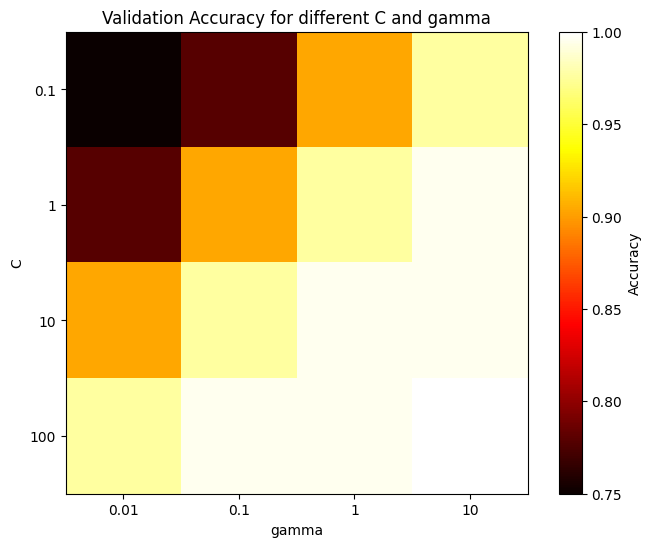

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

C_range = [0.1, 1, 10, 100]
gamma_range = [0.01, 0.1, 1, 10]

# ماتریس دقت را برای ترکیب های پارامترها
scores = np.zeros((len(C_range), len(gamma_range)))

# حلقه روی پارامترها و آموزش مدل و محاسبه دقت
for i, C in enumerate(C_range):
    for j, gamma in enumerate(gamma_range):
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        scores[i, j] = accuracy_score(y_val, y_pred)

# رسم Heatmap دقت
plt.figure(figsize=(8, 6))
plt.imshow(scores, interpolation='nearest', cmap=plt.cm.hot)
plt.xlabel('gamma')
plt.ylabel('C')
plt.colorbar(label='Accuracy')
plt.xticks(np.arange(len(gamma_range)), gamma_range)
plt.yticks(np.arange(len(C_range)), C_range)
plt.title('Validation Accuracy for different C and gamma')
plt.show()


رسم نمودار و مشخص کردن مرز تصمیم

<Figure size 1000x700 with 0 Axes>

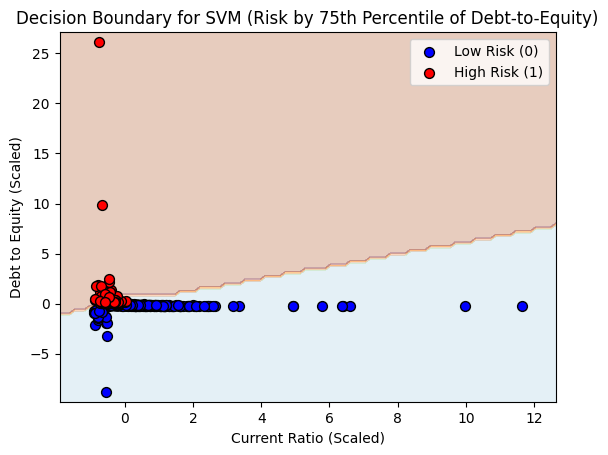

In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
import numpy as np

csv_path = Path("/content/drive/My Drive/Zahra/financial_ratios.csv")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

for col in ['current_ratio', 'debt_to_equity']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ساخت ستون برچسب بر اساس صدک ۷۵ debt_to_equity
p75 = df['debt_to_equity'].quantile(0.75, interpolation="midpoint")
df['risk_label'] = (df['debt_to_equity'] > p75).astype(int)

df = df.dropna(subset=['current_ratio', 'debt_to_equity', 'risk_label'])

# انتخاب ویژگی‌ها و هدف
features = ['current_ratio', 'debt_to_equity']
X = df[features].values
y = df['risk_label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

svm_model = SVC(kernel='poly', class_weight='balanced')
svm_model.fit(X_train, y_train)

# رسم مرز تصمیم
plt.figure(figsize=(10, 7))
disp = DecisionBoundaryDisplay.from_estimator(
    svm_model,
    X_train,
    response_method='predict',
    alpha=0.3,
    cmap=plt.cm.Paired,
    xlabel='Current Ratio (Scaled)',
    ylabel='Debt to Equity (Scaled)'
)

colors = ['blue', 'red']
labels = ['Low Risk (0)', 'High Risk (1)']
for idx, label in enumerate(np.unique(y_train)):
    plt.scatter(
        X_train[y_train == label, 0],
        X_train[y_train == label, 1],
        c=colors[idx],
        label=labels[idx],
        edgecolors='k',
        s=50
    )
plt.title('Decision Boundary for SVM (Risk by 75th Percentile of Debt-to-Equity)')
plt.legend()
plt.show()

________________________________________________________________________________________________________________________________________________________________

# گزارش سوم: امتیاز دهی بر اساس  ریسک شرکت ها

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
risk_features = [
    'debt_to_equity',
    'current_ratio',
    'return_on_assets',
    'return_on_equity',
    'net_profit_margin',
    'operating_margin',
    'asset_turnover'
]

df_clean = df[risk_features].dropna().copy()

نرمال سازی

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(df_clean)

# تبدیل به DataFrame با همان نام ستون‌ها
norm_df = pd.DataFrame(normalized_features, columns=risk_features)

In [ ]:
import numpy as np

weights = np.full(len(risk_features), 1 / len(risk_features))  # وزن برابر برای همه ویژگی‌ها
# محاسبه Risk Score
df_clean['risk_score'] = np.dot(norm_df, weights)

df_result = df.loc[df_clean.index].copy()
df_result['risk_score'] = df_clean['risk_score']

In [ ]:
df_result['risk_level'] = pd.qcut(df_result['risk_score'], q=3, labels=['Low', 'Medium', 'High'])

print(df_result['risk_level'].value_counts())

risk_level
Low       347
High      347
Medium    346
Name: count, dtype: int64


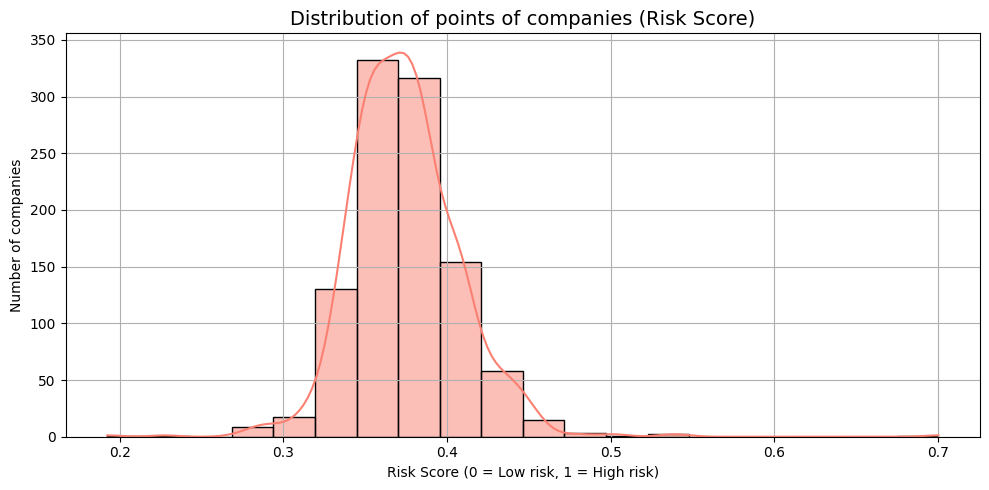

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(df_result['risk_score'], bins=20, kde=True, color='salmon')
plt.title("Distribution of points of companies (Risk Score)", fontsize=14)
plt.xlabel("Risk Score (0 = Low risk, 1 = High risk)")
plt.ylabel("Number of companies")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df_result[['Firm', 'Year', 'risk_score', 'risk_level']].head(20)

,Firm,Year,risk_score,risk_level
0,البرزدارو,1394,0.401370,High
1,البرزدارو,1395,0.395073,High
2,البرزدارو,1396,0.384835,Medium
3,البرزدارو,1397,0.371260,Medium
4,البرزدارو,1398,0.380866,Medium
5,البرزدارو,1399,0.378889,Medium
6,البرزدارو,1400,0.376823,Medium
7,البرزدارو,1401,0.381119,Medium
8,اما,1394,0.372808,Medium
9,اما,1395,0.381875,Medium


سال‌های ۱۳۹۴ و ۱۳۹۵، هر کدام ۲ بار در دیتافریم ظاهر شدند

بقیه سال‌ها (۱۳۹۶ تا ۱۴۰۱) هرکدام فقط یک بار وجود دارند

In [ ]:
df_result.to_csv("final_risk_scored_companies.csv", index=False)

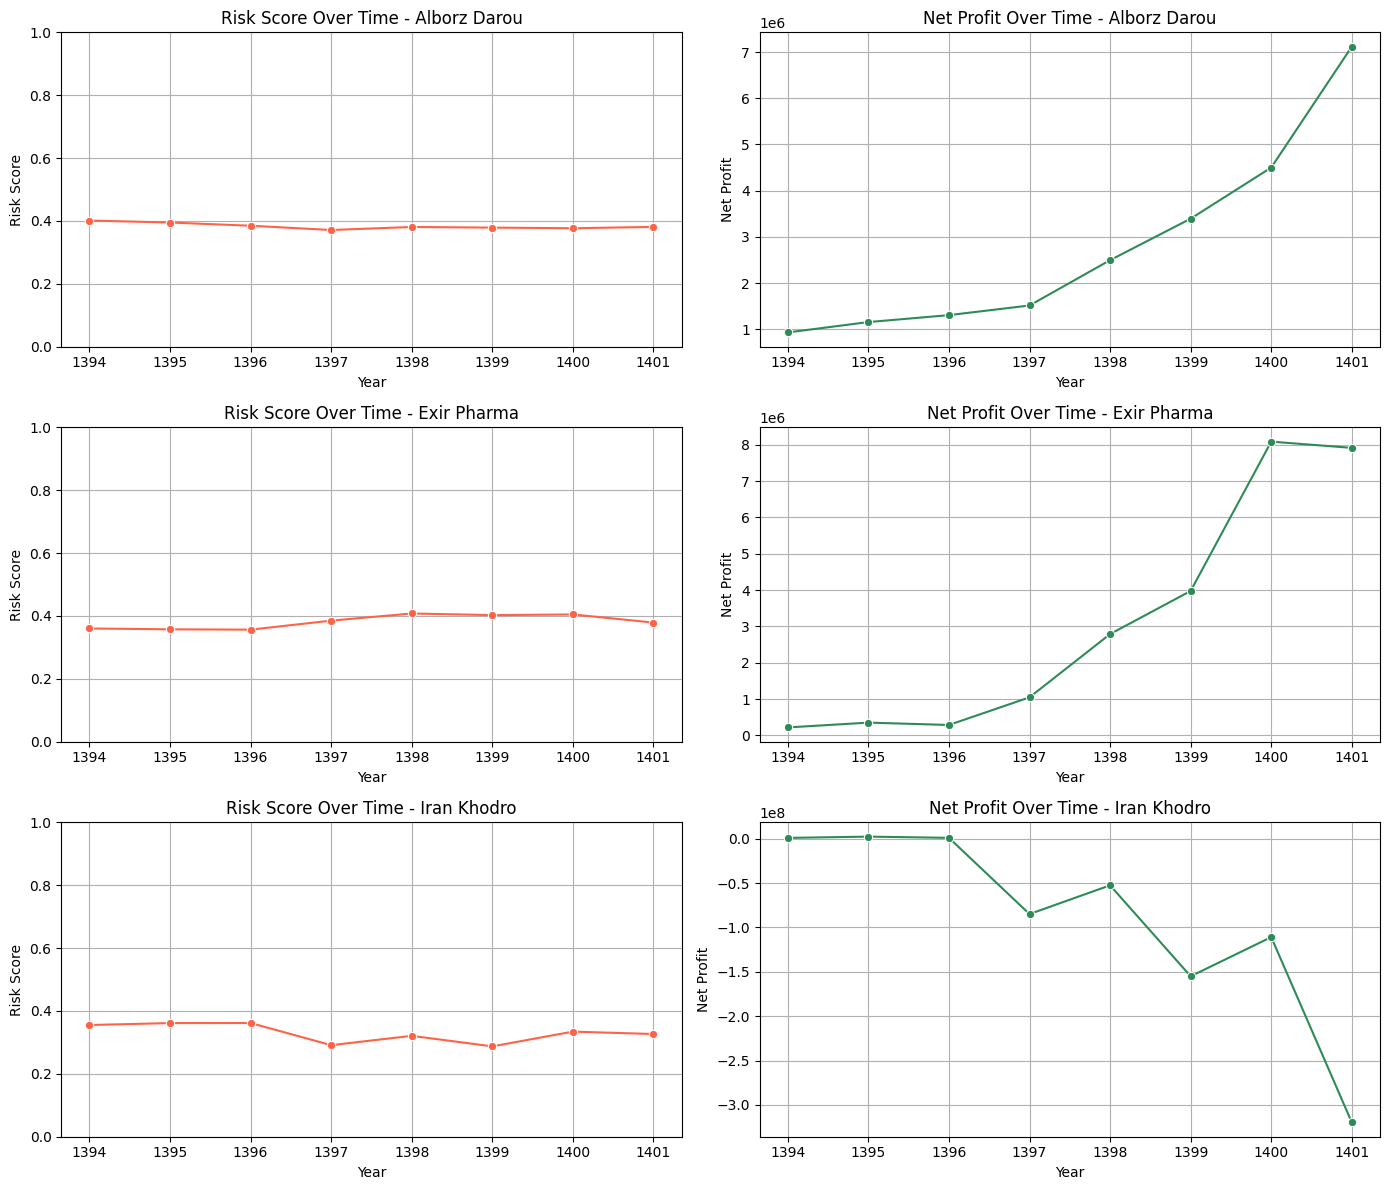

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/financial_ratios.csv")
df.columns = df.columns.str.strip()

raw_df = pd.read_excel("/content/drive/My Drive/Zahra/IranStockExchange.xlsx", sheet_name="Sheet1")
raw_df.columns = raw_df.columns.str.strip()

risk_features = [
    'debt_to_equity', 'current_ratio', 'return_on_assets',
    'return_on_equity', 'net_profit_margin',
    'operating_margin', 'asset_turnover'
]

df_clean = df[risk_features].dropna().copy()
scaler = MinMaxScaler()
normalized = scaler.fit_transform(df_clean)
norm_df = pd.DataFrame(normalized, columns=risk_features)
weights = np.full(len(risk_features), 1 / len(risk_features))
df_clean['risk_score'] = np.dot(norm_df, weights)

df_result = df.loc[df_clean.index].copy()
df_result['risk_score'] = df_clean['risk_score']
df_result['risk_level'] = pd.qcut(df_result['risk_score'], q=3, labels=['Low', 'Medium', 'High'])

profit_df = raw_df[['Firm', 'Year', 'net profit']].copy()
profit_df.columns = ['Firm', 'Year', 'net_profit']
merged_df = pd.merge(df_result, profit_df, on=['Firm', 'Year'], how='inner')

company_map = {
    'البرزدارو': 'Alborz Darou',
    'دارو اکسیر': 'Exir Pharma',
    'ایران خودرو': 'Iran Khodro'
}

companies = list(company_map.keys())

plt.figure(figsize=(14, len(companies) * 4))

for i, company_fa in enumerate(companies):
    company_en = company_map[company_fa]
    company_df = merged_df[merged_df['Firm'] == company_fa].sort_values('Year')

    # Risk Score plot
    plt.subplot(len(companies), 2, 2*i+1)
    sns.lineplot(data=company_df, x='Year', y='risk_score', marker='o', color='tomato')
    plt.title(f'Risk Score Over Time - {company_en}', fontsize=12)
    plt.xlabel("Year")
    plt.ylabel("Risk Score")
    plt.ylim(0, 1)
    plt.grid(True)

    # Net Profit plot
    plt.subplot(len(companies), 2, 2*i+2)
    sns.lineplot(data=company_df, x='Year', y='net_profit', marker='o', color='seagreen')
    plt.title(f'Net Profit Over Time - {company_en}', fontsize=12)
    plt.xlabel("Year")
    plt.ylabel("Net Profit")
    plt.grid(True)

plt.tight_layout()
plt.show()


_____________________________________________________

## [**SVM**](https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/)

طبقه بندی بر اساس لیبل سود آوری(طبقه بندی دودویی)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# 1. بارگذاری داده‌ها
data = pd.read_csv('financial_ratios.csv')  # فرض کنید فایل CSV نسبت‌های مالی شماست

# 2. تعریف لیبل (مثال: سودآوری بر اساس ROA)
data['Label'] = (data['return_on_assets'] > 0.05).astype(int)  # 1 برای سودآور، 0 برای غیرسودآور

# 3. انتخاب ویژگی‌ها (X) و لیبل (y)
X = data[['current_ratio', 'debt_to_equity', 'return_on_assets', 'return_on_equity', 'net_profit_margin']]  # مثال ویژگی‌ها
y = data['Label']

# 4. تقسیم داده به Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. نرمال‌سازی داده‌ها
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. آموزش مدل SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')  # کرنل RBF برای داده‌های غیرخطی
svm_model.fit(X_train_scaled, y_train)

# 7. ارزیابی مدل
y_pred = svm_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9807692307692307
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.99      0.99      0.99       137

    accuracy                           0.98       208
   macro avg       0.98      0.98      0.98       208
weighted avg       0.98      0.98      0.98       208



In [ ]:
import pandas as pd

# فرض کنید df داده‌های اصلی شماست
df = pd.read_csv('financial_ratios.csv')

# تعریف لیبل ریسک مالی
df['Risk_Label'] = (
    (df['debt_to_equity'] > 0.6) &
    (df['Operating cash flows for the current year'] < 0) &
    (df['return_on_assets'] < 0)
).astype(int)

# نمایش تعداد شرکت‌های پرریسک و کم‌ریسک
print(df['Risk_Label'].value_counts())

Risk_Label
0    1021
1      19
Name: count, dtype: int64


 کم ریسک میشه لیبل صفر و پر ریسک میشه لیبل یک

In [ ]:
# انتخاب ویژگی‌های مؤثر (X) و لیبل (y)
features = ['current_ratio', 'debt_to_equity', 'return_on_assets', 'return_on_equity', 'Operating cash flows for the current year']
X = df[features]
y = df['Risk_Label']

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# نرمال‌سازی داده‌ها
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# تقسیم داده به Train/Test (80% آموزش، 20% آزمون)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# مدل SVM با کرنل RBF (مناسب برای داده‌های غیرخطی)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

# پیش‌بینی روی داده آزمون
y_pred = svm_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9759615384615384

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       203
           1       0.00      0.00      0.00         5

    accuracy                           0.98       208
   macro avg       0.49      0.50      0.49       208
weighted avg       0.95      0.98      0.96       208


Confusion Matrix:
 [[203   0]
 [  5   0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}


In [ ]:
best_svm = SVC(kernel='rbf', C=10, gamma=0.1)
best_svm.fit(X_train, y_train)
y_pred_best = best_svm.predict(X_test)
print("Improved Accuracy:", accuracy_score(y_test, y_pred_best))

Improved Accuracy: 0.9759615384615384


In [ ]:
# فرض: شرکت‌هایی که سود خالص منفی دارند پرریسک (1) و مثبت کم‌ریسک (0)
df['Risk_Label'] = (df['net profit'] < 0).astype(int)

# حذف ردیف هایی که داده ناقص دارند
df = df.dropna(subset=['current_ratio', 'debt_to_equity', 'Risk_Label'])

features = ['current_ratio', 'debt_to_equity']
X = df[features].values
y = df['Risk_Label'].values

<Figure size 1000x700 with 0 Axes>

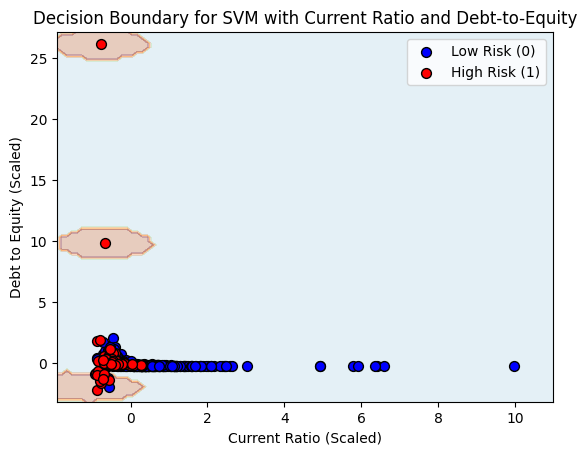

In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
import numpy as np

# مسیر فایل داده
csv_path = Path("/content/drive/My Drive/Zahra/financial_ratios.csv")

# خواندن داده
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# اطمینان از نوع عددی ستون‌های مورد نیاز
for col in ['current_ratio', 'debt_to_equity']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')



# مقیاس بندی داده ها
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# تقسیم به داده آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# تعریف مدل SVM با کرنل RBF
svm_model = SVC(kernel='rbf', C=1, gamma='scale', probability=True)

# آموزش مدل
svm_model.fit(X_train, y_train)

# رسم مرز تصمیم (Decision Boundary)

plt.figure(figsize=(10, 7))
disp = DecisionBoundaryDisplay.from_estimator(
    svm_model,
    X_train,
    response_method='predict',
    alpha=0.3,
    cmap=plt.cm.Paired,
    xlabel='Current Ratio (Scaled)',
    ylabel='Debt to Equity (Scaled)'
)

# نمایش داده‌ها روی نمودار برای هر کلاس با رنگ جدا
colors = ['blue', 'red']
labels = ['Low Risk (0)', 'High Risk (1)']
for idx, label in enumerate(np.unique(y_train)):
    plt.scatter(X_train[y_train == label, 0], X_train[y_train == label, 1],
                c=colors[idx], label=labels[idx], edgecolors='k', s=50)

plt.title('Decision Boundary for SVM with Current Ratio and Debt-to-Equity')
plt.legend()
plt.show()

In [ ]:
print(df.columns.tolist())

['ID', 'Firm', 'Year', 'Industry', 'Symbol', 'Cash', 'Short term investment', 'Tangible fixed assets', 'Current asset', 'Total assets', 'Current debt', 'debt', 'sale', 'tax', 'Profit before tax', 'net profit', 'Tax paid', 'Operating cash flows for the current year', 'current_ratio', 'debt_to_equity', 'net_profit_margin', 'return_on_assets', 'return_on_equity', 'gross_margin', 'operating_margin', 'asset_turnover']


In [ ]:
import joblib

# ذخیره مدل و اسکیلر
joblib.dump(best_svm, 'svm_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# بارگذاری مجدد
loaded_model = joblib.load('svm_risk_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

________________________________________________________________________________

# **مدل** رگرسیون چند متغیره

In [ ]:
year_count = df.groupby('Firm')['Year'].nunique().reset_index()
print(year_count.head(10))
print('میانگین سال‌های موجود:', year_count["Year"].mean())

                Firm  Year
0              آبسال     8
1              آذراب     8
2            آلومراد     8
3    آلومینیوم ایران     8
4     آهنگری تراکتور     8
5          البرزدارو     8
6  الکتریک خودرو شرق     8
7                اما     8
8         ایران تایر     8
9      ایران ترانسفو     8
میانگین سال‌های موجود: 8.0


مدل اول: پیش بینی سود خالص سال بعد

In [ ]:
df['net profit'] = pd.to_numeric(df['net profit'], errors='coerce')

df = df.sort_values(['Firm', 'Year'])
df['net_profit_next'] = df.groupby('Firm')['net profit'].shift(-1)

df_model = df.dropna(subset=['net_profit_next']).copy()

In [ ]:
features = [
    'current_ratio', 'debt_to_equity', 'return_on_assets',
    'asset_turnover', 'sale', 'Current asset', 'debt'
]
features = [c for c in features if c in df_model.columns]   # نگه‌داشتن ستون‌های موجود

X = df_model[features].fillna(df_model[features].median())
y = df_model['net_profit_next']

In [ ]:
X_train = X[df_model['Year'] < 1400]
y_train = y[df_model['Year'] < 1400]

X_test  = X[df_model['Year'] == 1400]
y_test  = y[df_model['Year'] == 1400]

In [ ]:
print(X_test.shape)

(130, 7)


In [ ]:
print(df_model['Year'].unique())

[1394 1395 1396 1397 1398 1399 1400]


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
!pip uninstall -y scikit-learn
!pip install -U scikit-learn

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 52.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.


In [ ]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error.__module__)

sklearn.metrics._regression


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print("نمونه‌های Train (اولی 5 ردیف):")
print(X_train.head())
print("\nهدف Train (y_train - 5 نمونه اول):")
print(y_train.head())

print("\nنمونه‌های Test (اولی 5 ردیف):")
print(X_test.head())
print("\nهدف Test (y_test - 5 نمونه اول):")
print(y_test.head())

print("\nمقادیر پیش‌بینی شده (5 نمونه اول):")
print(y_pred[:5])

# 3. مقایسه دقیق چند مقدار واقعی و پیش‌بینی شده
comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})
print("\nمقایسه مقادیر واقعی و پیش‌بینی شده (10 نمونه اول):")
print(comparison_df)

print("\nتعداد مقادیر یکتا در y_test:", y_test.nunique())
print("مقادیر یکتا در y_test:", y_test.unique())

print("\nتعداد نمونه‌های Train:", len(X_train))
print("تعداد نمونه‌های Test:", len(X_test))

print("\nآیا در y_pred مقدار NaN وجود دارد؟", pd.isna(y_pred).any())


نمونه‌های Train (اولی 5 ردیف):
    current_ratio  debt_to_equity  return_on_assets  asset_turnover  \
48       1.383296        2.000127          0.013042        0.825486   
49       1.399931        2.129248          0.012924        0.738904   
50       1.352454        2.679547          0.000568        0.709716   
51       1.621082        1.596440          0.111212        0.932523   
52       2.013112        1.157176          0.204684        1.089894   

         sale  Current asset     debt  
48  1291955.0        1304235  1043412  
49  1130881.0        1288393  1041394  
50  1251642.0        1543525  1284288  
51  1733422.0        1636152  1142928  
52  2622888.0        2163816  1290950  

هدف Train (y_train - 5 نمونه اول):
48      19780.0
49       1002.0
50     206726.0
51     492582.0
52    1390882.0
Name: net_profit_next, dtype: float64

نمونه‌های Test (اولی 5 ردیف):
     current_ratio  debt_to_equity  return_on_assets  asset_turnover  \
54        2.243063        0.953404          0

مدل عملکرد خوبی نداشته است

مدل دوم: پیش بینی سود خالص

 R-squared (R²): 1.0000
📉 Mean Squared Error (MSE): 0.00
📉 Mean Absolute Error (MAE): 0.01


/tmp/ipython-input-60-3620038500.py:53: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


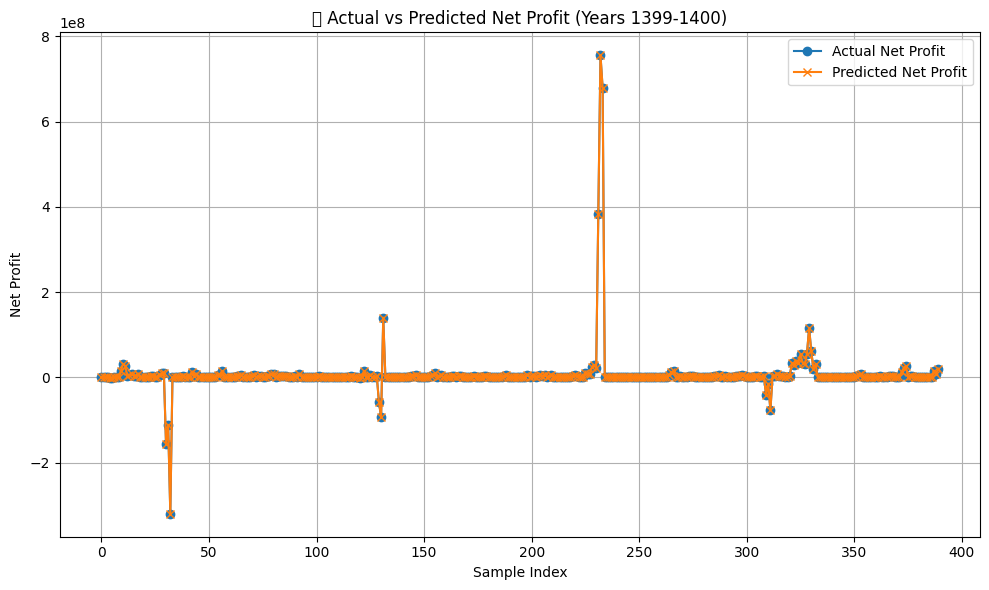

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


# حذف ستون‌های غیرعددی
cols_to_drop = ['ID', 'Firm', 'Symbol', 'Industry']
df_num = df.drop(columns=cols_to_drop)

# تقسیم بر اساس سال:
train_data = df_num[df_num['Year'] <= 1398]
test_data = df_num[df_num['Year'] >= 1399]

# جدا کردن ویژگی‌ها و هدف
X_train = train_data.drop(columns=['net profit', 'Year'])
y_train = train_data['net profit']

X_test = test_data.drop(columns=['net profit', 'Year'])
y_test = test_data['net profit']

# جایگزینی مقادیر گمشده با میانگین (از روی Train)
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # مهمه که از میانگین Train استفاده بشه

# ساخت و آموزش مدل
model = LinearRegression()
model.fit(X_train, y_train)

# پیش‌بینی
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f" R-squared (R²): {r2:.4f}")


# محاسبه خطاها
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"📉 Mean Squared Error (MSE): {mse:.2f}")
print(f"📉 Mean Absolute Error (MAE): {mae:.2f}")

#  رسم نمودار مقایسه‌ای
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual Net Profit', marker='o')
plt.plot(y_pred, label='Predicted Net Profit', marker='x')
plt.title('📈 Actual vs Predicted Net Profit (Years 1399-1400)')
plt.xlabel('Sample Index')
plt.ylabel('Net Profit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print("تعداد نمونه‌های آموزش:", len(X_train))
print("تعداد نمونه‌های تست:", len(X_test))

# آیا نمونه‌ای در هر دو مجموعه مشترک هست؟
common_indices = set(X_train.index).intersection(set(X_test.index))
print("تعداد نمونه‌های مشترک بین آموزش و تست:", len(common_indices))

تعداد نمونه‌های آموزش: 650
تعداد نمونه‌های تست: 390
تعداد نمونه‌های مشترک بین آموزش و تست: 0


In [ ]:
print("نمونه‌ای از X_train:")
print(X_train.head())

print("\nنمونه‌ای از y_train:")
print(y_train.head())

print("\nنمونه‌ای از X_test:")
print(X_test.head())

print("\nنمونه‌ای از y_test:")
print(y_test.head())

print("\nنمونه‌ای از y_pred (پیش‌بینی):")
print(y_pred[:5])

نمونه‌ای از X_train:
      Cash  Short term investment  Tangible fixed assets  Current asset  \
48   26783                      0                 249813        1304235   
49   34465                      0                 229497        1288393   
50   27804                      0                 207699        1543525   
51  116515                      0                 197814        1636152   
52   75257                      0                 230795        2163816   

    Total assets  Current debt     debt       sale     tax  Profit before tax  \
48       1565085        942846  1043412  1291955.0    5060              25472   
49       1530484        920326  1041394  1130881.0    5155              24935   
50       1763581       1141277  1284288  1251642.0       0               1002   
51       1858851       1009296  1142928  1733422.0   38072             244798   
52       2406554       1074861  1290950  2622888.0  116478             609060   

    ...  Operating cash flows for the cur

In [ ]:
corr = df_num.corr()
print("همبستگی ویژگی‌ها با net profit:")
print(corr['net profit'].sort_values(ascending=False))

همبستگی ویژگی‌ها با net profit:
net profit                                   1.000000
Profit before tax                            0.999523
tax                                          0.913057
Tax paid                                     0.896348
net_profit_next                              0.878170
Operating cash flows for the current year    0.851480
Short term investment                        0.844479
Current asset                                0.795775
Total assets                                 0.664299
Cash                                         0.600870
sale                                         0.431590
Tangible fixed assets                        0.295705
return_on_assets                             0.202140
debt                                         0.132259
return_on_equity                             0.123200
Current debt                                 0.121466
operating_margin                             0.104374
net_profit_margin                            0.102

In [ ]:
print("ستون‌های موجود در داده‌های ویژگی‌ها:")
print(X_train.columns)

# ببین ستون net profit داخل X نیست
print("'net profit' in X_train columns?", 'net profit' in X_train.columns)

ستون‌های موجود در داده‌های ویژگی‌ها:
Index(['Cash', 'Short term investment', 'Tangible fixed assets',
       'Current asset', 'Total assets', 'Current debt', 'debt', 'sale', 'tax',
       'Profit before tax', 'Tax paid',
       'Operating cash flows for the current year', 'current_ratio',
       'debt_to_equity', 'net_profit_margin', 'return_on_assets',
       'return_on_equity', 'gross_margin', 'operating_margin',
       'asset_turnover', 'net_profit_next'],
      dtype='object')
'net profit' in X_train columns? False


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")

# نمونه‌هایی که خطا خیلی کوچیکه
errors = y_test - y_pred
print("نمونه‌هایی که خطا نزدیک صفر است (<= 1e-6):")
print(errors[abs(errors) <= 1e-6])

R-squared: 1.0
نمونه‌هایی که خطا نزدیک صفر است (<= 1e-6):
Series([], Name: net profit, dtype: float64)


In [ ]:
print(X_train.columns.tolist())

['Cash', 'Short term investment', 'Tangible fixed assets', 'Current asset', 'Total assets', 'Current debt', 'debt', 'sale', 'tax', 'Profit before tax', 'Tax paid', 'Operating cash flows for the current year', 'current_ratio', 'debt_to_equity', 'net_profit_margin', 'return_on_assets', 'return_on_equity', 'gross_margin', 'operating_margin', 'asset_turnover', 'net_profit_next']


In [ ]:
cols_to_remove = [
    'tax',
    'Profit before tax',
    'Tax paid',
    'Operating cash flows for the current year',
    'net_profit_next',
    'net_profit_margin',
    'return_on_assets',
    'return_on_equity',
    'gross_margin',
    'operating_margin',
    'asset_turnover'

]

X_train_clean = X_train.drop(columns=cols_to_remove)
X_test_clean = X_test.drop(columns=cols_to_remove)

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

# مقدار آلفا (مقدار منظم‌سازی) رو می‌تونی تنظیم کنی
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train_clean, y_train)

y_pred = lasso.predict(X_test_clean)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# نمایش وزن ویژگی‌ها
coef = pd.Series(lasso.coef_, index=X_train_clean.columns)
print("Feature coefficients:\n", coef)


MSE: 502313385407075.75
R2: 0.8581017276660807
Feature coefficients:
 Cash                        -0.820984
Short term investment        0.420202
Tangible fixed assets        0.252434
Current asset                0.254789
Total assets                 0.254209
Current debt                 0.304246
debt                        -0.868222
sale                         0.059479
current_ratio           -17084.691020
debt_to_equity           -7721.824743
dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.645e+15, tolerance: 5.778e+12
  model = cd_fast.enet_coordinate_descent(


In [ ]:
model = LinearRegression()
model.fit(X_train_clean, y_train)
y_pred = model.predict(X_test_clean)
r2 = r2_score(y_test, y_pred)
print(f" R-squared (R²): {r2:.4f}")

 R-squared (R²): 0.8612


In [ ]:
from sklearn.metrics import mean_absolute_error
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 4137229.4758474217


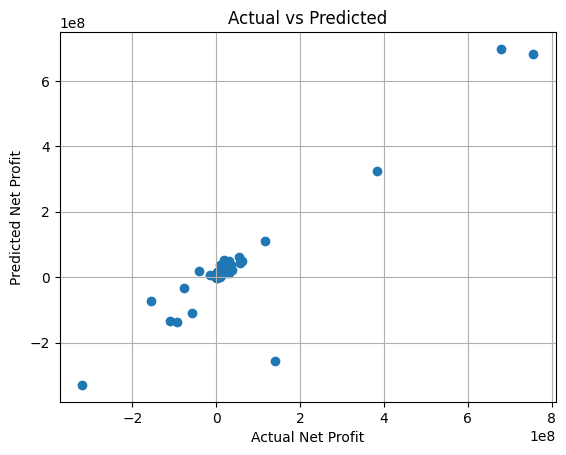

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Net Profit")
plt.ylabel("Predicted Net Profit")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()
model.fit(X_train, y_train)
r2 = model.score(X_test, y_test)
print(f"R² Score: {r2:.2f}")

R² Score: 0.40


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4)
model.fit(X_train, y_train)
r2 = model.score(X_test, y_test)
print(f"R2: {r2:.4f}")

R2: 0.3684


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")


MSE: 0.0003
MAE: 0.0066


In [ ]:
import numpy as np

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")

RMSE: 0.0186


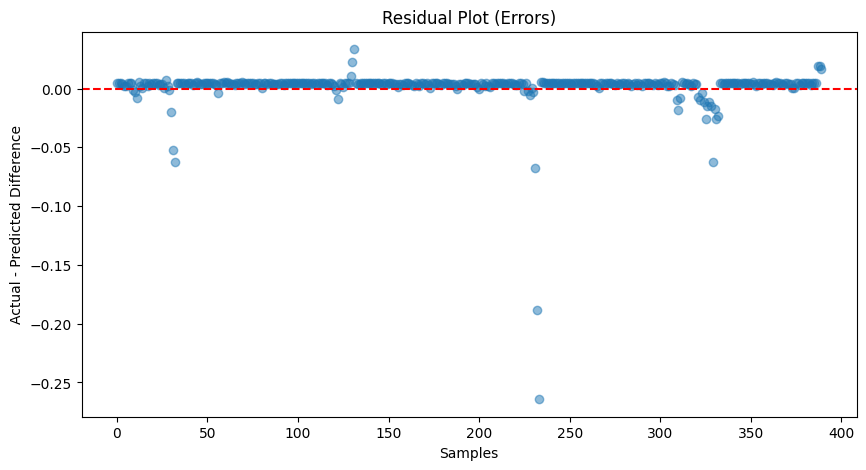

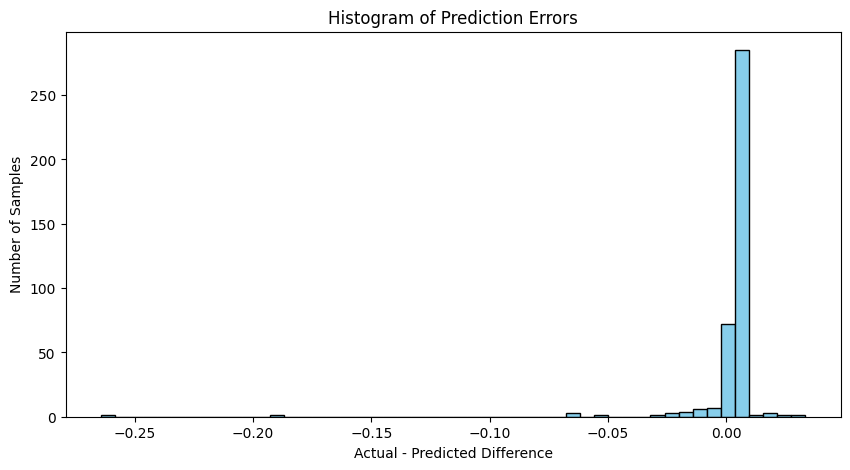

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals (errors)
errors = y_test - y_pred

# Residual plot
plt.figure(figsize=(10, 5))
plt.scatter(range(len(errors)), errors, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Errors)')
plt.xlabel('Samples')
plt.ylabel('Actual - Predicted Difference')
plt.show()

# Histogram of errors
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Prediction Errors')
plt.xlabel('Actual - Predicted Difference')
plt.ylabel('Number of Samples')
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('gbr',    GradientBoostingRegressor(random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('MAE :', mean_absolute_error(y_test, y_pred))
print('RMSE:', mean_squared_error(y_test, y_pred))
print('R²  :',  r2_score(y_test, y_pred))

MAE : 5679726.134242401
RMSE: 2127883732603444.2
R²  : 0.3988951237300097


In [ ]:
import pandas as pd
pd.DataFrame({'واقعی': y_test, 'پیش‌بینی': y_pred}).head(10)


,واقعی,پیش‌بینی
53,1390882,1.275632e+06
54,1041768,9.977999e+05
55,795173,7.611346e+05
61,1981,3.431798e+03
62,-366421,-3.279838e+05
63,-428855,-4.170502e+05
685,231662,2.231814e+05
686,193957,1.860064e+05
687,201127,1.942968e+05
877,15650714,1.592693e+07


بهبود مدل اول برای پیش بینی سود خالص سال بعد

In [ ]:
print(df.columns.tolist())

['ID', 'Firm', 'Year', ' Industry', 'Symbol', 'Cash', 'Short term investment', 'Tangible fixed assets', 'Current asset', 'Total assets', 'Current debt', 'debt', 'sale', 'tax', 'Profit before tax', 'net profit', 'Tax paid', 'Operating cash flows for the current year', 'net_profit_next']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Remove non-numeric and textual columns
cols_to_drop = ['ID', 'Firm', 'Symbol', 'Industry']
df.columns = df.columns.str.strip()  # Clean column names just in case
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df_model = df.drop(columns=cols_to_drop)

# 2. Drop rows with missing target
df_model = df_model.dropna(subset=['net_profit_next'])

# 3. Split data based on time
train_data = df_model[df_model['Year'] <= 1398].copy()
test_data = df_model[df_model['Year'] >= 1399].copy()

# 4. Define features and target
X_train = train_data.drop(columns=['net_profit_next', 'Year'])
y_train = train_data['net_profit_next']

X_test = test_data.drop(columns=['net_profit_next', 'Year'])
y_test = test_data['net_profit_next']

# 5. Fill missing values with train mean
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

# 6. Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Predict on test data
y_pred = model.predict(X_test)

# 8. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"MAE: {mae:,.0f}")
print(f"MSE: {mse:,.0f}")
print(f"R2 Score: {r2:.2f}")

# 9. Sample comparison of actual vs predicted
comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})
print("\nFirst 10 samples comparison:")
print(comparison_df)

Model Evaluation:
MAE: 9,571,403
MSE: 3,354,000,582,585,685
R2 Score: 0.27

First 10 samples comparison:
       Actual     Predicted
0   1041768.0  4.310797e+06
1    795173.0  3.085201e+06
2   -366421.0  6.686205e+05
3   -428855.0  4.983564e+05
4    193957.0  2.655955e+03
5    201127.0 -8.030912e+04
6  31479067.0  3.065248e+07
7  27738012.0  2.749470e+07
8   6164658.0  7.709780e+06
9   7314921.0  8.203314e+06


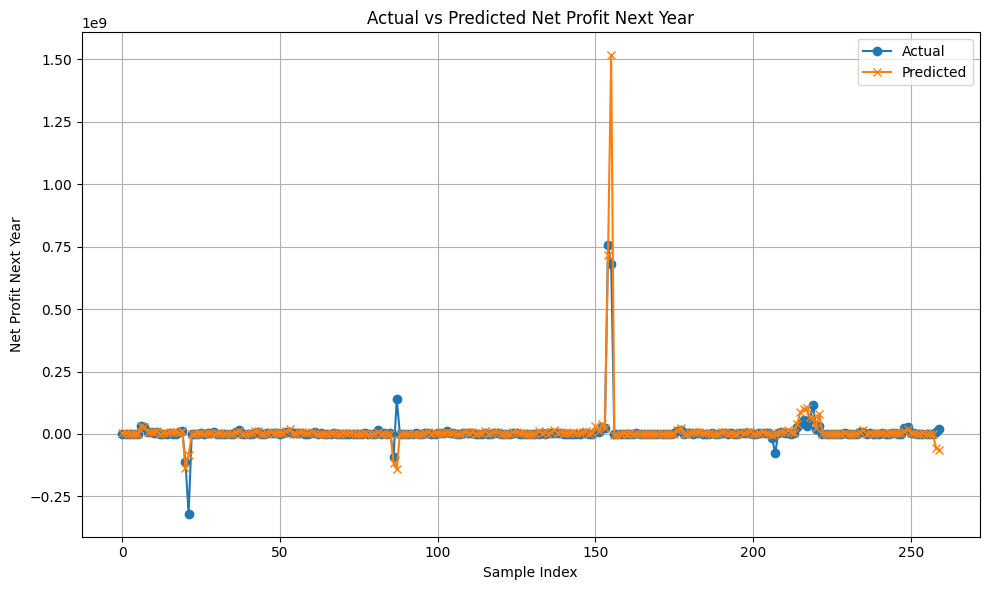

In [ ]:
# 10. Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Net Profit Next Year')
plt.xlabel('Sample Index')
plt.ylabel('Net Profit Next Year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

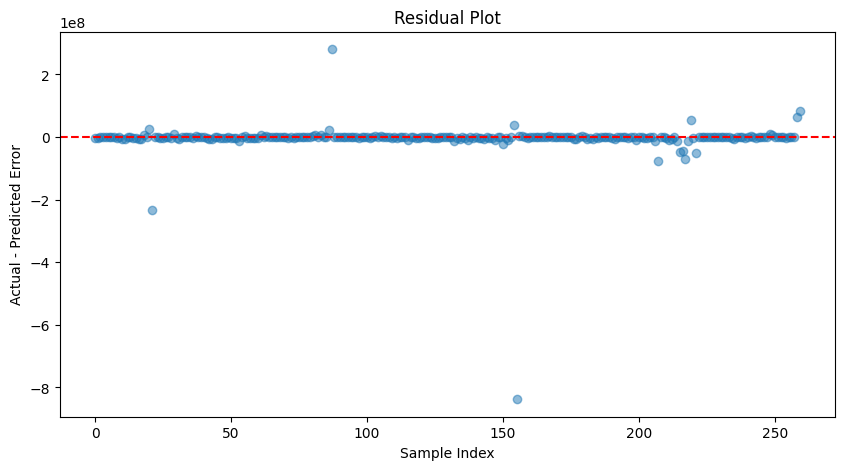

In [ ]:
# 11. Residual plot
errors = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(range(len(errors)), errors, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Sample Index')
plt.ylabel('Actual - Predicted Error')
plt.show()

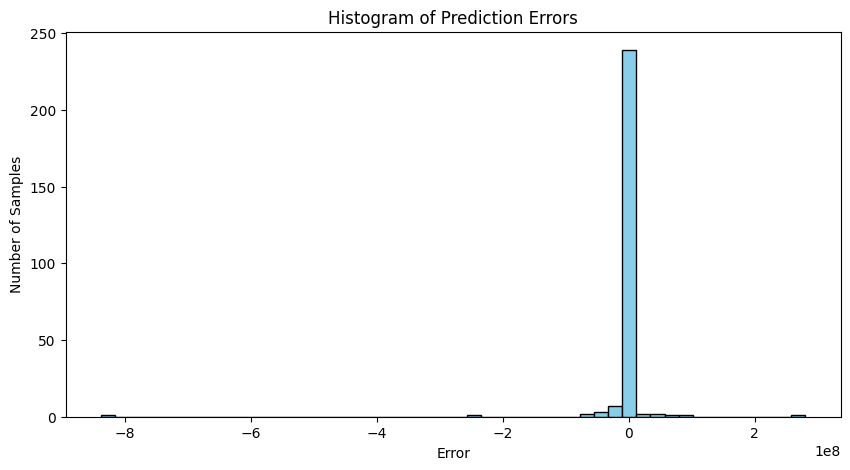

In [ ]:
# 12. Histogram of errors
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Prediction Errors')
plt.xlabel('Error')
plt.ylabel('Number of Samples')
plt.show()

XGBoost Model Evaluation:
MAE: 10,765,099
MSE: 3,939,407,567,763,528
R2 Score: 0.14

First 10 samples comparison:
       Actual     Predicted
0   1041768.0  3.294913e+06
1    795173.0  1.923844e+06
2   -366421.0  6.060258e+02
3   -428855.0  1.250548e+02
4    193957.0  3.077880e+05
5    201127.0  2.075700e+05
6  31479067.0  3.091770e+07
7  27738012.0  4.603660e+06
8   6164658.0  1.492807e+06
9   7314921.0  7.476812e+06


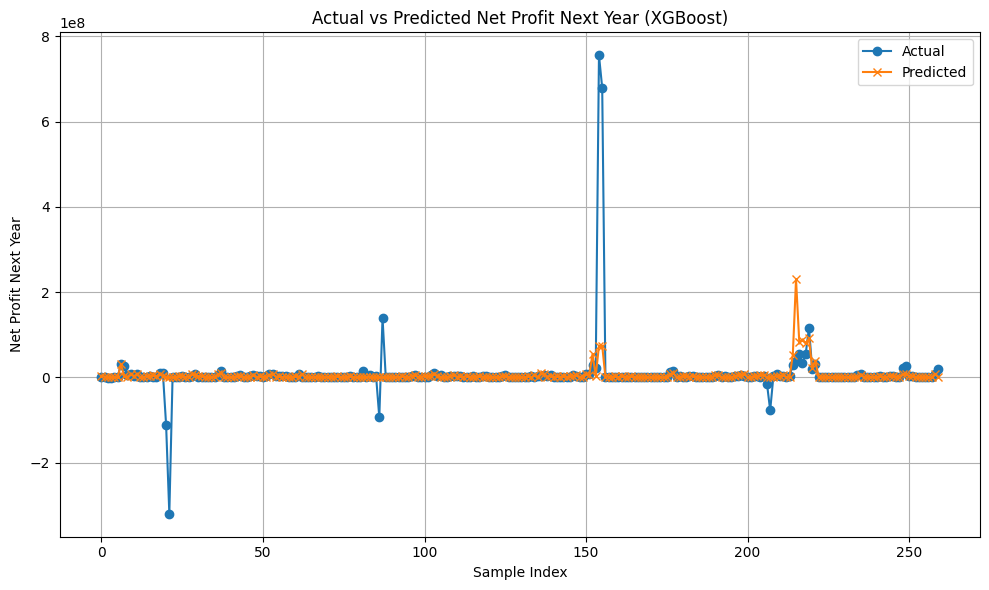

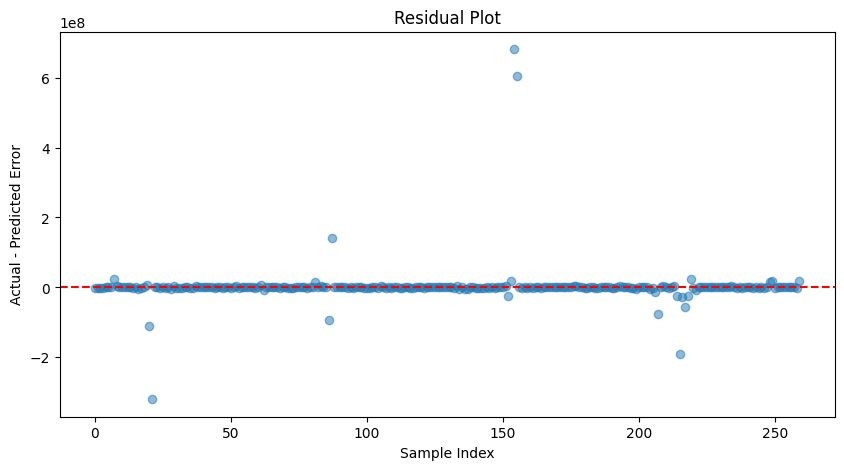

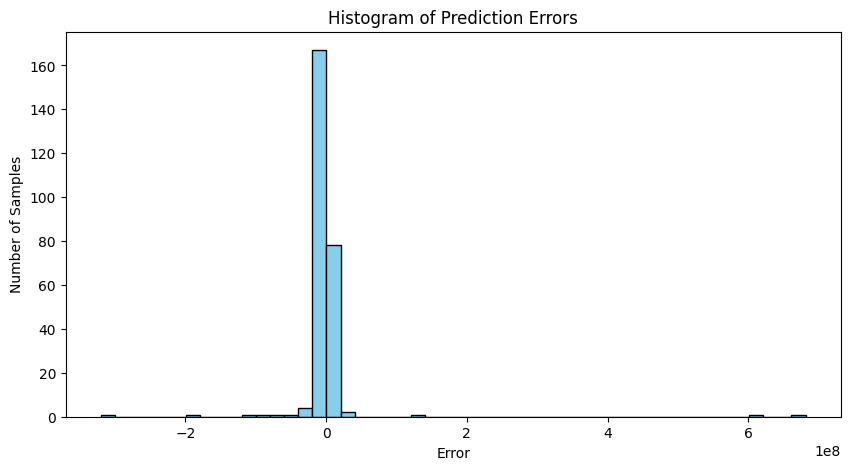

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- 1. پاک‌سازی نام ستون‌ها (حذف فاصله اضافی)
df.columns = df.columns.str.strip()

# --- 2. حذف ستون‌های غیرعددی
cols_to_drop = ['ID', 'Firm', 'Symbol', 'Industry']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df_model = df.drop(columns=cols_to_drop)

# --- 3. حذف ردیف‌هایی که هدف ندارند
df_model = df_model.dropna(subset=['net_profit_next'])

# --- 4. تقسیم داده‌ها بر اساس سال
train_data = df_model[df_model['Year'] <= 1398].copy()
test_data = df_model[df_model['Year'] >= 1399].copy()

# --- 5. تعریف ویژگی‌ها و هدف
X_train = train_data.drop(columns=['net_profit_next', 'Year'])
y_train = train_data['net_profit_next']

X_test = test_data.drop(columns=['net_profit_next', 'Year'])
y_test = test_data['net_profit_next']

# --- 6. پر کردن مقادیر گمشده با میانگین از روی Train
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

# --- 7. تبدیل لگاریتمی هدف برای کنترل مقادیر بزرگ (اختیاری ولی پیشنهاد میشه)
y_train_log = np.log1p(y_train.clip(lower=0))
y_test_log = np.log1p(y_test.clip(lower=0))

# --- 8. ساخت و آموزش مدل XGBoost
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train_log)

# --- 9. پیش‌بینی و تبدیل معکوس لگاریتمی
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

# --- 10. ارزیابی مدل
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost Model Evaluation:")
print(f"MAE: {mae:,.0f}")
print(f"MSE: {mse:,.0f}")
print(f"R2 Score: {r2:.2f}")

# --- 11. نمایش مقایسه 10 نمونه اول
comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})
print("\nFirst 10 samples comparison:")
print(comparison_df)

# --- 12. نمودار مقایسه واقعی و پیش‌بینی
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Net Profit Next Year (XGBoost)')
plt.xlabel('Sample Index')
plt.ylabel('Net Profit Next Year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 13. نمودار باقی‌مانده‌ها (Residuals)
errors = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(range(len(errors)), errors, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Sample Index')
plt.ylabel('Actual - Predicted Error')
plt.show()

# --- 14. هیستوگرام خطاها
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Prediction Errors')
plt.xlabel('Error')
plt.ylabel('Number of Samples')
plt.show()

مدل اول عملکرد خوبی حتی پس از بهبود هم ندارد